# 08 — Neraca, Atribusi, dan Batas Kejujurannya

Notebook 07 berhenti di pertanyaan *"berapa kilogram minyak ada di truk
ini"*. Notebook ini melanjutkan ke dua pertanyaan yang jauh lebih sulit,
karena jawabannya menentukan siapa yang membayar:

| Model | Pertanyaan | Yang dipertaruhkan |
|---|---|---|
| **Model 5** | Ke mana perginya selisih antara potensi dan hasil? | pembagian tanggung jawab |
| **Model 6** | Kehilangan pabrik itu **karena apa**? | tuduhan atas satu pihak |

## Kenapa neraca tiga baris, bukan dua

Neraca dua baris berbentuk *"potensi teoretis dikurangi kehilangan"*.
Dengan bentuk itu buah mentah muncul **dua kali**: sekali karena
menurunkan kandungan minyak yang masuk pabrik, sekali lagi karena
pabrik yang memproses buah mentah memang mencatat kehilangan lebih
tinggi. Petani dipotong dua kali untuk satu kesalahan yang sama.

Baris tengah memutus rantai itu. Setelah potensi realistis dihitung,
urusan buah mentah selesai — sisanya urusan pabrik.

## Yang membuat Model 6 berbeda dari klasifikasi biasa

Model 6 **tidak pernah melihat label kerusakan**. Di pabrik nyata label
itu memang tidak ada; tidak ada operator yang mencatat *"hari ini
sterilizer kurang tekanan"* dalam bentuk yang bisa dilatih. Metode yang
butuh label hanya bisa didemokan, tidak bisa dipasang.

Jadi Model 6 harus menemukan sendiri berapa banyak pola kerusakan yang
ada, memulihkan bentuk tiap pola, dan mengakui ketika sesuatu tidak
cocok dengan apa pun. Notebook ini mengukur apakah pola yang ia temukan
benar-benar pola yang ditanam — atau kebetulan yang kelihatan
meyakinkan.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parents[1]))
import vizstyle as vs
vs.apply_style()

from ai.simulator.mill import ALIRAN, GANGGUAN, Pabrik
from ai.reasoning import balance as M5
from ai.reasoning.attribution import Model6
from ai.evaluation import rule_recovery as RR

LBL = [a.replace("_", " ") for a in ALIRAN]
W_PEMASOK, W_PABRIK = vs.CATEGORICAL[1], vs.CATEGORICAL[0]
W_SISA = vs.INK_MUTED

df = Pabrik(seed=42).riwayat(400)
print(f"riwayat giling: {len(df)} hari")
print(df.groupby("_gangguan").size().rename("hari").to_frame().T.to_string())

riwayat giling: 400 hari
_gangguan  cst_dingin  kempa_aus  normal  perebusan_berlebih  perebusan_kurang_matang  sludge_separator_tersumbat
hari               37         28     256                  41                       14                          24


## 1. Simulator dulu — dan kenapa ia boleh dipercaya sejauh apa

Data proses harian pabrik tidak publik. Meminta satu pun angka rendemen
harian berarti meminta data yang jadi dasar sengketa harga pabrik itu
dengan pemasoknya sendiri. Simulator yang seluruh koefisiennya
terpublikasi adalah penggantinya yang jujur — dan lebih baik untuk
pengujian, karena kebenarannya diketahui.

Yang **tidak** boleh diklaim: bahwa simulator ini memvalidasi Model 5
terhadap kenyataan. Yang divalidasi adalah bahwa aritmetika neracanya
benar dan atribusinya bisa memulihkan gangguan yang ditanam.

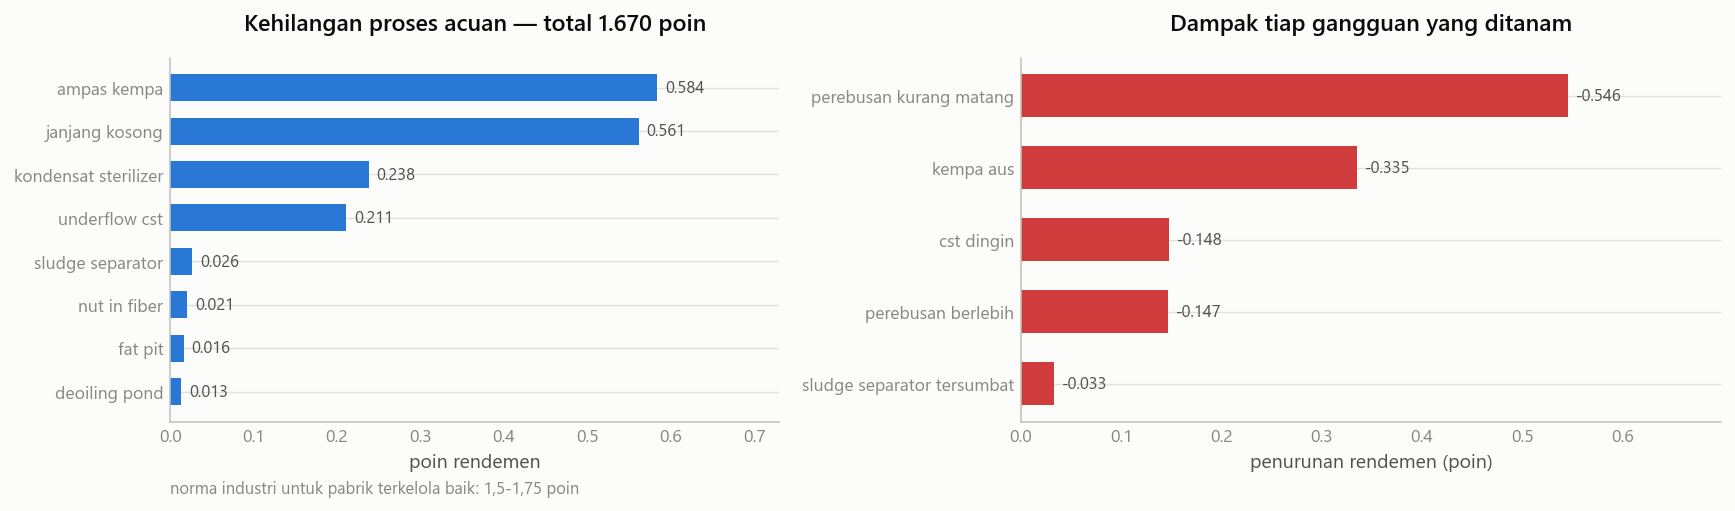

  norma                  LULUS
  tertutup               LULUS
  deterministik          LULUS
  seed_beda              LULUS
  arah                   LULUS
  cocok_model4           LULUS
  masuk_akal             LULUS


In [2]:
from ai.simulator.mill import swauji
h = swauji(verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8),
                         gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
p0 = Pabrik(seed=1, ragam_proses=0.0)
poin = [p0.kadar_acuan[a] * p0.nisbah[a] for a in ALIRAN]
urut = np.argsort(poin)[::-1]
b = ax.barh([LBL[i] for i in urut][::-1], [poin[i] for i in urut][::-1],
            color=vs.CATEGORICAL[0], height=0.62)
for r, v in zip(b, [poin[i] for i in urut][::-1]):
    ax.annotate(f"{v:.3f}", (v, r.get_y() + r.get_height()/2),
                xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=vs.INK_SECONDARY)
ax.set_xlabel("poin rendemen")
ax.set_title(f"Kehilangan proses acuan — total {sum(poin):.3f} poin")
vs.caption(ax, "norma industri untuk pabrik terkelola baik: 1,5-1,75 poin")
ax.set_xlim(0, max(poin) * 1.25)

ax = axes[1]
t = h["penurunan_per_gangguan"]
nama = sorted(t, key=lambda k: -t[k])
b = ax.barh([n.replace("_", " ") for n in nama][::-1],
            [t[n] for n in nama][::-1],
            color=vs.STATUS["critical"], height=0.6)
for r, v in zip(b, [t[n] for n in nama][::-1]):
    ax.annotate(f"-{v:.3f}", (v, r.get_y() + r.get_height()/2),
                xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=vs.INK_SECONDARY)
ax.set_xlabel("penurunan rendemen (poin)")
ax.set_title("Dampak tiap gangguan yang ditanam")
ax.set_xlim(0, max(t.values()) * 1.28)
plt.tight_layout(); vs.show()

for k in ["lulus_norma", "lulus_tertutup", "lulus_deterministik",
          "lulus_seed_beda", "lulus_arah", "lulus_cocok_model4",
          "lulus_masuk_akal"]:
    print(f"  {k[6:]:22s} {'LULUS' if h[k] else 'GAGAL'}")

> Uji `cocok_model4` bukan formalitas: konvensi penalti kematangan
> sempat meleset **100×** di sini (fraksi vs persen), dan neraca tetap
> terlihat masuk akal karena angkanya kebetulan mendarat di dekat
> rendemen petani swadaya yang terpublikasi. Yang menangkapnya adalah
> pemeriksaan silang antar modul, bukan mata.

## 2. Kartu neraca — bentuk yang dilihat pengguna

Inilah keluaran yang benar-benar dipakai: air terjun tiga baris yang
menunjukkan ke mana perginya setiap poin rendemen.

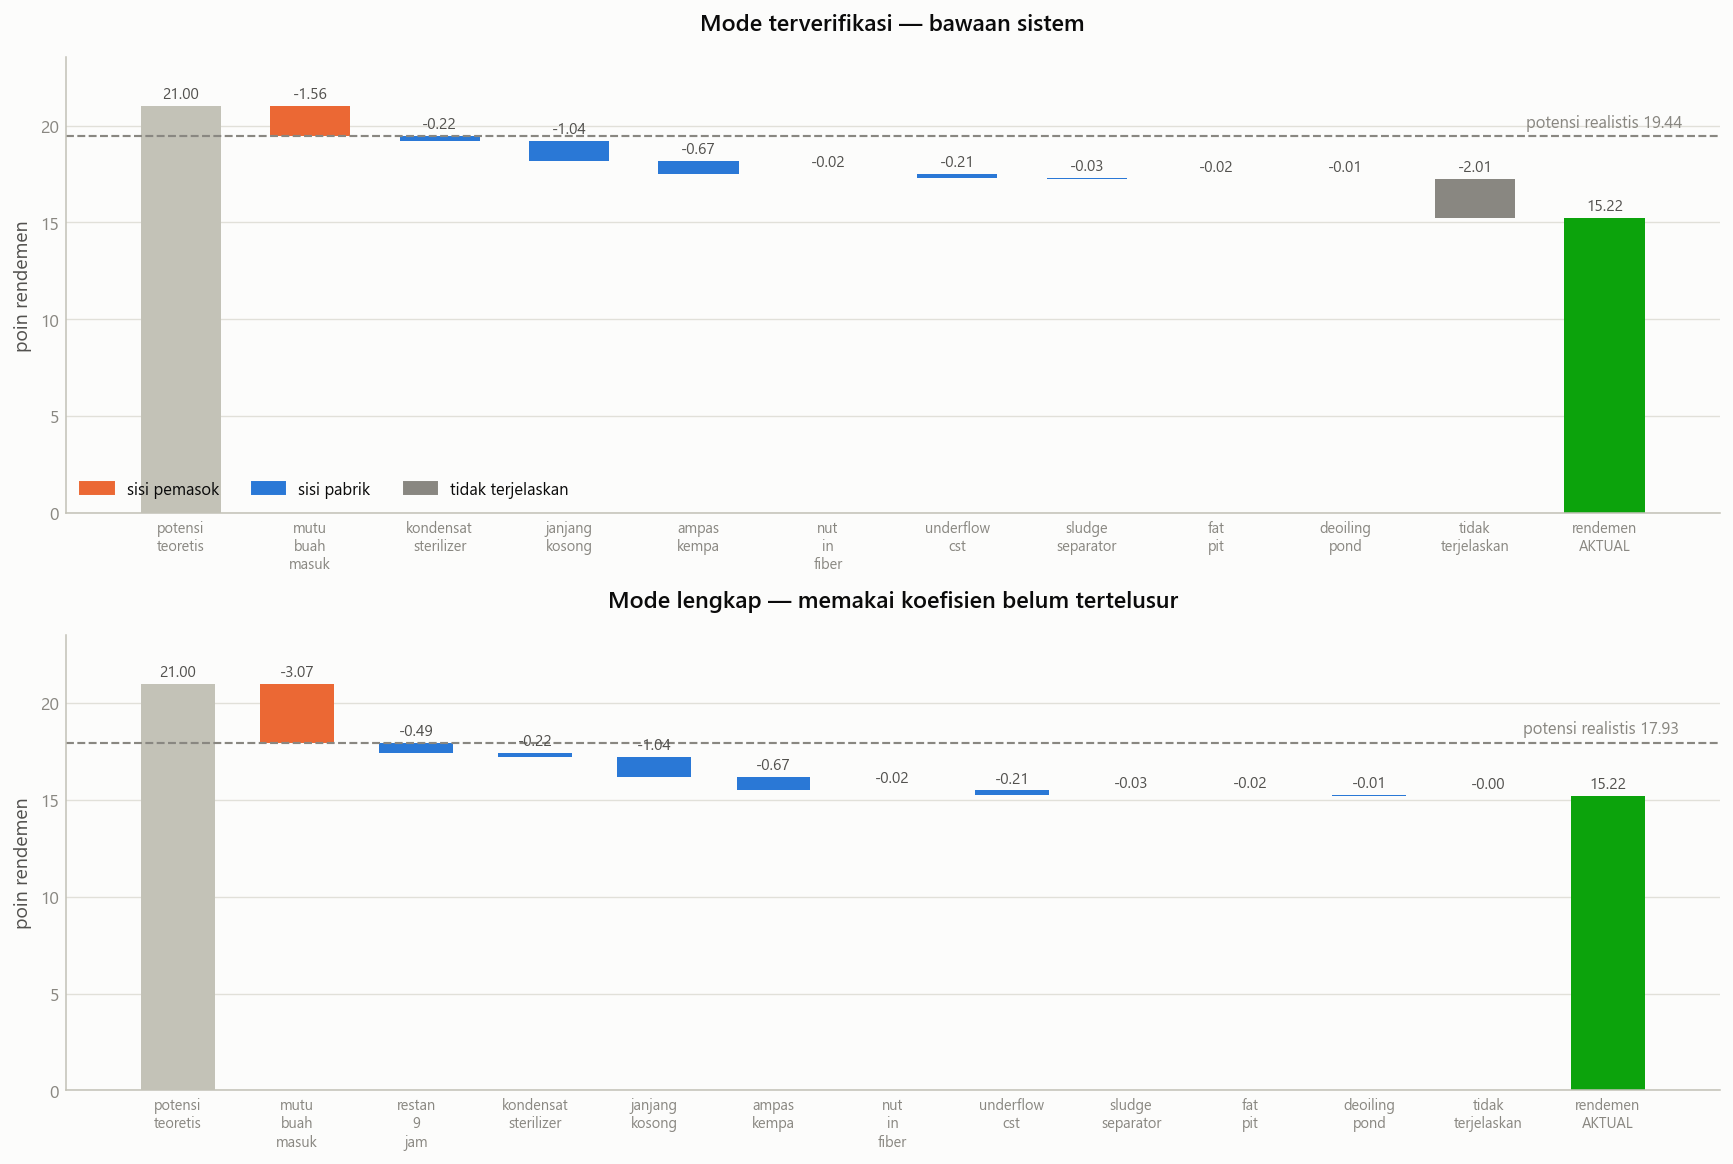

galat penutupan aritmetika: ketat 0.00e+00  lengkap 0.00e+00


In [3]:
def waterfall(ax, kartu, judul):
    nama = ["potensi\nteoretis"]
    nilai = [kartu.oer_teoretis]
    warna = [vs.BASELINE]
    jenis = ["mulai"]

    for b in kartu.rugi_pemasok:
        nama.append(b.nama.replace(" ", "\n")); nilai.append(b.poin)
        warna.append(W_PEMASOK); jenis.append("delta")
    for b in kartu.rugi_pabrik:
        nama.append(b.nama.replace(" ", "\n")); nilai.append(b.poin)
        warna.append(W_PABRIK); jenis.append("delta")
    b = kartu.tak_terjelaskan
    nama.append("tidak\nterjelaskan"); nilai.append(b.poin)
    warna.append(W_SISA); jenis.append("delta")
    nama.append("rendemen\nAKTUAL"); nilai.append(kartu.oer_aktual)
    warna.append(vs.STATUS["good"]); jenis.append("akhir")

    dasar, kum = [], 0.0
    for v, j in zip(nilai, jenis):
        if j == "mulai":
            dasar.append(0.0); kum = v
        elif j == "delta":
            kum += v
            dasar.append(kum if v < 0 else kum - v)
        else:
            dasar.append(0.0)

    tinggi = [abs(v) if j == "delta" else v for v, j in zip(nilai, jenis)]
    x = np.arange(len(nama))
    ax.bar(x, tinggi, bottom=dasar, color=warna, width=0.62)
    for i, (v, j) in enumerate(zip(nilai, jenis)):
        atas = dasar[i] + tinggi[i]
        ax.annotate(f"{v:+.2f}" if j == "delta" else f"{v:.2f}",
                    (i, atas), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, color=vs.INK_SECONDARY)
    # garis potensi realistis
    ax.axhline(kartu.oer_realistis, color=vs.INK_MUTED,
               linestyle="--", linewidth=1.1)
    ax.annotate(f"potensi realistis {kartu.oer_realistis:.2f}",
                (len(nama) - 0.4, kartu.oer_realistis), xytext=(0, 5),
                textcoords="offset points", ha="right", fontsize=8.5,
                color=vs.INK_MUTED)
    ax.set_xticks(x); ax.set_xticklabels(nama, fontsize=7.5)
    ax.set_ylabel("poin rendemen")
    ax.set_title(judul)
    ax.set_ylim(0, kartu.oer_teoretis * 1.12)
    ax.grid(axis="x", visible=False)


komposisi = {"mentah": 0.12, "kurang_masak": 0.18, "masak": 0.65,
             "terlalu_masak": 0.05}
BERAT = 240_000.0
hasil = Pabrik(seed=42, ragam_proses=0.0).olah(
    komposisi, BERAT, jam_restan=9.0, gangguan="perebusan_kurang_matang")

k_ketat = M5.dari_simulator(hasil, BERAT, komposisi, jam_restan=9.0)
k_lengkap = M5.dari_simulator(hasil, BERAT, komposisi, jam_restan=9.0,
                              mode="lengkap")

fig, axes = plt.subplots(2, 1, figsize=(12.5, 8.4))
waterfall(axes[0], k_ketat, "Mode terverifikasi — bawaan sistem")
waterfall(axes[1], k_lengkap, "Mode lengkap — memakai koefisien belum tertelusur")
axes[0].legend(handles=[Patch(color=W_PEMASOK, label="sisi pemasok"),
                        Patch(color=W_PABRIK, label="sisi pabrik"),
                        Patch(color=W_SISA, label="tidak terjelaskan")],
               fontsize=8.5, loc="lower left", ncol=3)
plt.tight_layout(); vs.show()

print(f"galat penutupan aritmetika: ketat {k_ketat.galat_penutupan():.2e}  "
      f"lengkap {k_lengkap.galat_penutupan():.2e}")

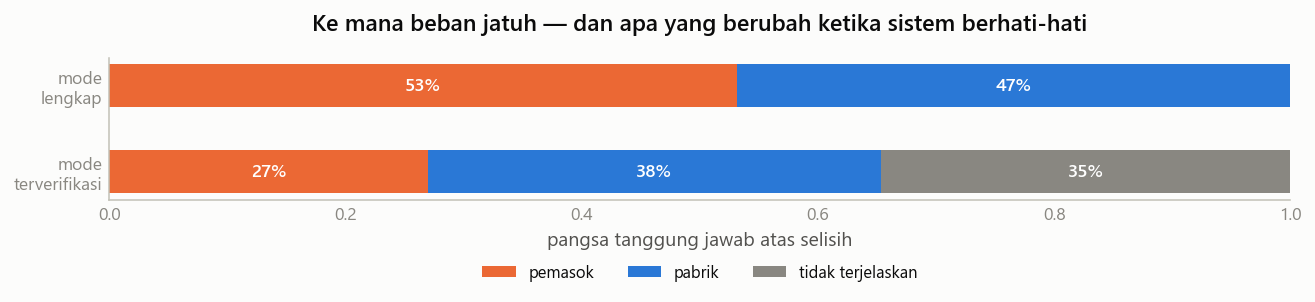

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 2.6))
mode = ["mode\nterverifikasi", "mode\nlengkap"]
kartu = [k_ketat, k_lengkap]
kiri = np.zeros(2)
for kunci, warna, label in [("pemasok", W_PEMASOK, "pemasok"),
                            ("pabrik", W_PABRIK, "pabrik"),
                            ("tidak_terjelaskan", W_SISA, "tidak terjelaskan")]:
    v = np.array([k.bagi_tanggung_jawab()[kunci] for k in kartu])
    ax.barh(mode, v, left=kiri, color=warna, height=0.5, label=label)
    for i, (a, b) in enumerate(zip(kiri, v)):
        if b > 0.04:
            ax.annotate(f"{b:.0%}", (a + b/2, i), ha="center", va="center",
                        fontsize=9.5, color="white", fontweight="600")
    kiri += v
ax.set_xlim(0, 1); ax.set_xlabel("pangsa tanggung jawab atas selisih")
ax.set_title("Ke mana beban jatuh — dan apa yang berubah ketika sistem berhati-hati")
ax.legend(fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3)
ax.grid(axis="y", visible=False)
plt.tight_layout(); vs.show()

> **Selisih dua mode itu adalah harga kehati-hatian, dan harganya
> terlihat.** Mode bawaan menolak tiga koefisien yang belum tertelusur
> ke sumber terbit. Akibatnya pangsa pemasok turun dari 53% ke 27%, dan
> yang tidak jadi dituduhkan **tidak dipindahkan ke pabrik** — ia muncul
> sebagai 35% ketidaktahuan yang diakui terbuka.
>
> Bahwa sisa di mode lengkap tepat nol adalah buktinya: aritmetika
> neracanya eksak, sehingga 2,005 poin di mode terverifikasi benar-benar
> berasal dari koefisien yang ditolak — bukan dari salah hitung.

## 3. Buah mentah tidak dihitung dua kali — dibuktikan, bukan dijanjikan

Klaim keadilan tidak boleh berhenti sebagai paragraf di proposal. Yang
diperiksa: menaikkan proporsi buah mentah harus menggerakkan baris
pemasok, **dan tidak boleh menyentuh baris pabrik sama sekali**.

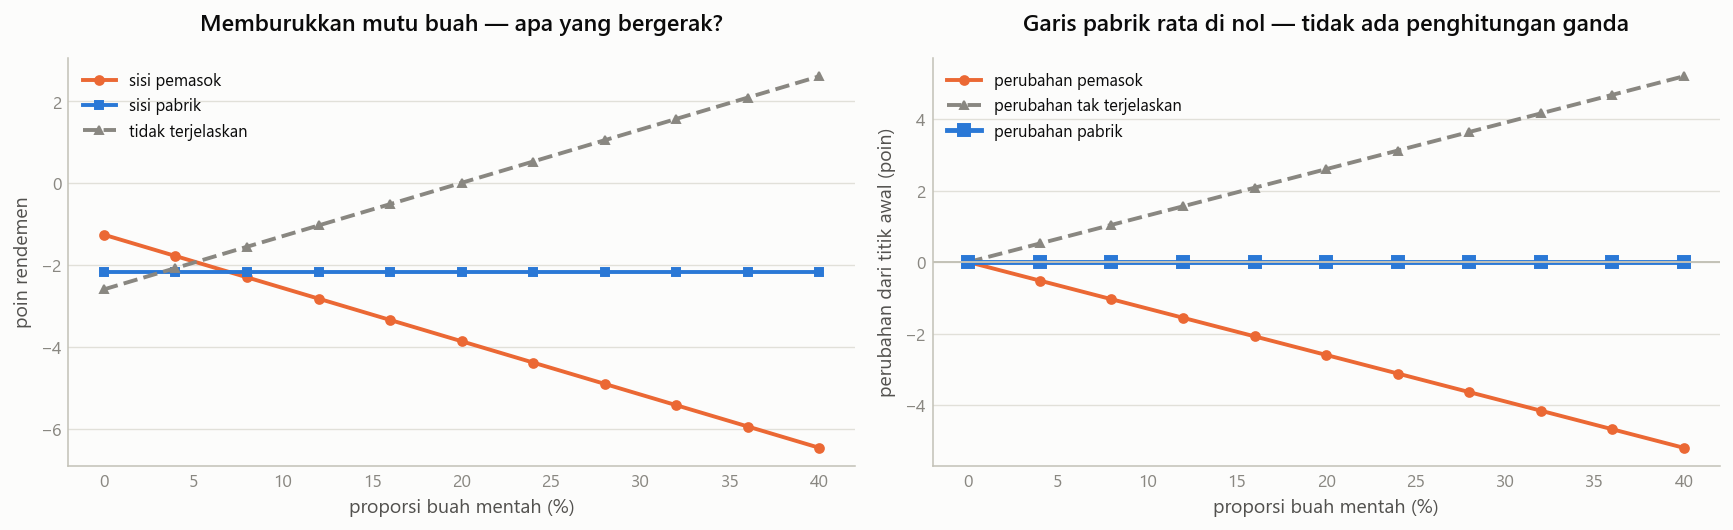

pergeseran maksimum sisi pabrik: 0.00e+00 poin
pemasok + tak terjelaskan selalu berjumlah tetap: 2.66e-15 poin


In [5]:
hilang = {k: abs(v) for k, v in
          Pabrik(seed=42, ragam_proses=0.0).olah(
              {"mentah": 0.02, "masak": 0.98}, BERAT).kehilangan_aliran.items()}

pct = np.arange(0, 0.42, 0.04)
pem, pab, sisa = [], [], []
for p in pct:
    komp = {"mentah": p, "kurang_masak": 0.15, "terlalu_masak": 0.04,
            "masak": max(0.0, 1 - p - 0.19)}
    s = sum(komp.values()); komp = {k: v/s for k, v in komp.items()}
    kk = M5.susun(komp, BERAT, 36_000.0, kehilangan_pabrik_poin=hilang,
                  jam_restan=9.0, mode="lengkap")
    pem.append(kk.total_pemasok_poin)
    pab.append(kk.total_pabrik_poin)
    sisa.append(kk.tak_terjelaskan.poin)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

ax = axes[0]
ax.plot(pct*100, pem, color=W_PEMASOK, marker="o", markersize=4.5,
        label="sisi pemasok")
ax.plot(pct*100, pab, color=W_PABRIK, marker="s", markersize=4.5,
        label="sisi pabrik")
ax.plot(pct*100, sisa, color=W_SISA, marker="^", markersize=4.5,
        linestyle="--", label="tidak terjelaskan")
ax.set_xlabel("proporsi buah mentah (%)")
ax.set_ylabel("poin rendemen")
ax.set_title("Memburukkan mutu buah — apa yang bergerak?")
ax.legend(fontsize=8.5)

ax = axes[1]
d_pab = np.array(pab) - pab[0]
d_pem = np.array(pem) - pem[0]
d_sisa = np.array(sisa) - sisa[0]
ax.plot(pct*100, d_pem, color=W_PEMASOK, marker="o", markersize=4.5,
        label="perubahan pemasok")
ax.plot(pct*100, d_sisa, color=W_SISA, marker="^", markersize=4.5,
        linestyle="--", label="perubahan tak terjelaskan")
ax.plot(pct*100, d_pab, color=W_PABRIK, marker="s", markersize=6,
        linewidth=2.5, label="perubahan pabrik")
ax.axhline(0, color=vs.BASELINE, linewidth=1)
ax.set_xlabel("proporsi buah mentah (%)")
ax.set_ylabel("perubahan dari titik awal (poin)")
ax.set_title("Garis pabrik rata di nol — tidak ada penghitungan ganda")
ax.legend(fontsize=8.5)
plt.tight_layout(); vs.show()

print(f"pergeseran maksimum sisi pabrik: {np.abs(d_pab).max():.2e} poin")
print(f"pemasok + tak terjelaskan selalu berjumlah tetap: "
      f"{np.abs(d_pem + d_sisa).max():.2e} poin")

> Garis pabrik **rata persis di nol** sepanjang seluruh rentang. Setiap
> poin yang ditambahkan ke tagihan pemasok diambil dari baris tak
> terjelaskan, bukan dicetak dari ketiadaan. Dua sifat itu yang membuat
> kartu neraca layak dibawa ke meja perundingan.

## 4. Model 6 menemukan kembali aturan yang tidak pernah diberitahukan

Simulator menanam lima jenis kerusakan, masing-masing menaikkan
beberapa aliran sekaligus dengan pola khas. Model 6 hanya melihat
delapan angka laboratorium per hari — tidak pernah nama kerusakannya,
tidak pernah jumlahnya.

Kalau pola yang ia temukan berimpit dengan pola yang ditanam, itu
bukan klasifikasi: itu **penemuan kembali hubungan sebab-akibat**.

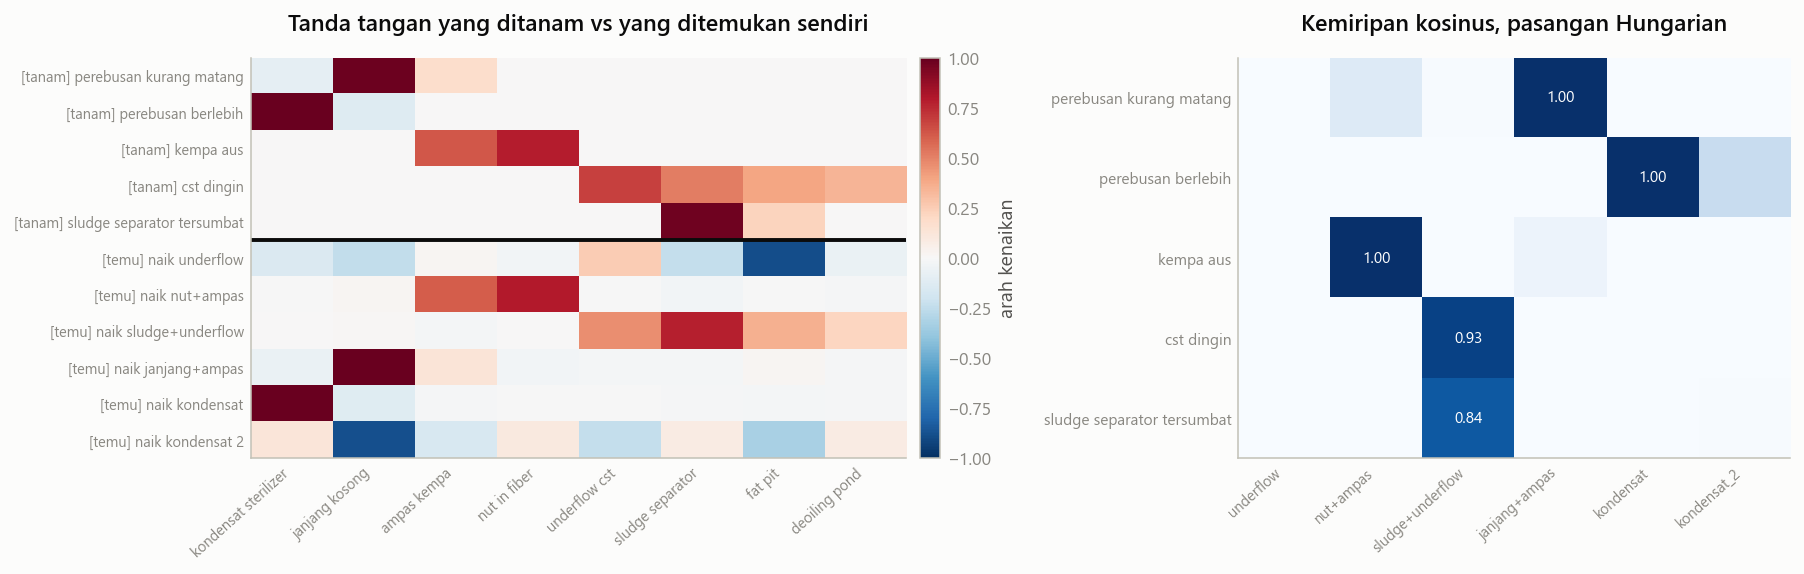

                  gangguan           pola_temuan  kosinus  pulih
   perebusan_kurang_matang    naik_janjang+ampas 0.997641   True
        perebusan_berlebih        naik_kondensat 0.999532   True
                 kempa_aus        naik_nut+ampas 0.999194   True
                cst_dingin naik_sludge+underflow 0.930728   True
sludge_separator_tersumbat      naik_kondensat_2 0.004223  False

pulih (kosinus >= 0.8): 4/5
siluet kelompok: 0.837


In [6]:
m = Model6(seed=42).pelajari(df)
ttd = RR.tanda_tangan_sebenarnya()
tabel = RR.cocokkan(m.pola_)

asli = list(ttd)
temu = list(m.pola_)
A = np.array([ttd[g] for g in asli])
B = np.array([m.pola_[p] for p in temu])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
gab = np.vstack([A, B])
im = ax.imshow(gab, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(ALIRAN)))
ax.set_xticklabels(LBL, rotation=42, ha="right", fontsize=7.5)
ax.set_yticks(range(len(gab)))
ax.set_yticklabels([f"[tanam] {g.replace('_',' ')}" for g in asli]
                   + [f"[temu] {p.replace('_',' ')}" for p in temu],
                   fontsize=7.5)
ax.axhline(len(asli) - 0.5, color=vs.INK, linewidth=2)
ax.set_title("Tanda tangan yang ditanam vs yang ditemukan sendiri")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="arah kenaikan")

ax = axes[1]
K = A @ B.T
im = ax.imshow(K, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(temu)))
ax.set_xticklabels([p.replace("naik_", "") for p in temu],
                   rotation=42, ha="right", fontsize=7.5)
ax.set_yticks(range(len(asli)))
ax.set_yticklabels([g.replace("_", " ") for g in asli], fontsize=8)
for i in range(len(asli)):
    for j in range(len(temu)):
        if K[i, j] > 0.35:
            ax.annotate(f"{K[i,j]:.2f}", (j, i), ha="center", va="center",
                        fontsize=8, color="white" if K[i, j] > 0.7 else vs.INK)
ax.set_title("Kemiripan kosinus, pasangan Hungarian")
ax.grid(False)
plt.tight_layout(); vs.show()

print(tabel.to_string(index=False))
print()
print(f"pulih (kosinus >= {RR.AMBANG_PULIH}): {tabel['pulih'].sum()}/{len(tabel)}")
print(f"siluet kelompok: {m.siluet_:.3f}")

> **Empat dari lima pulih, dengan kosinus 0,93 sampai 0,9995.** Dua arah
> acak di ruang delapan dimensi rata-rata berkosinus nol dengan simpangan
> sekitar 0,35 — angka setinggi itu bukan kebetulan.
>
> Yang kelima, `sludge_separator_tersumbat`, gagal. Sebabnya jelas dan
> bisa dihitung: tanda tangannya berimpit dengan `cst_dingin` karena
> keduanya menaikkan sludge separator dan fat pit. **Tidak ada metode
> tanpa label yang bisa memisahkan dua sebab yang meninggalkan jejak
> sama.** Batasnya ada di datanya, bukan di modelnya — dan cara
> menembusnya adalah menambah sensor, bukan menambah lapisan jaringan.

## 5. Apa yang terjadi kalau dunianya lebih kotor?

Tiga cara sistem ini bisa dibuat gagal, diuji satu per satu.

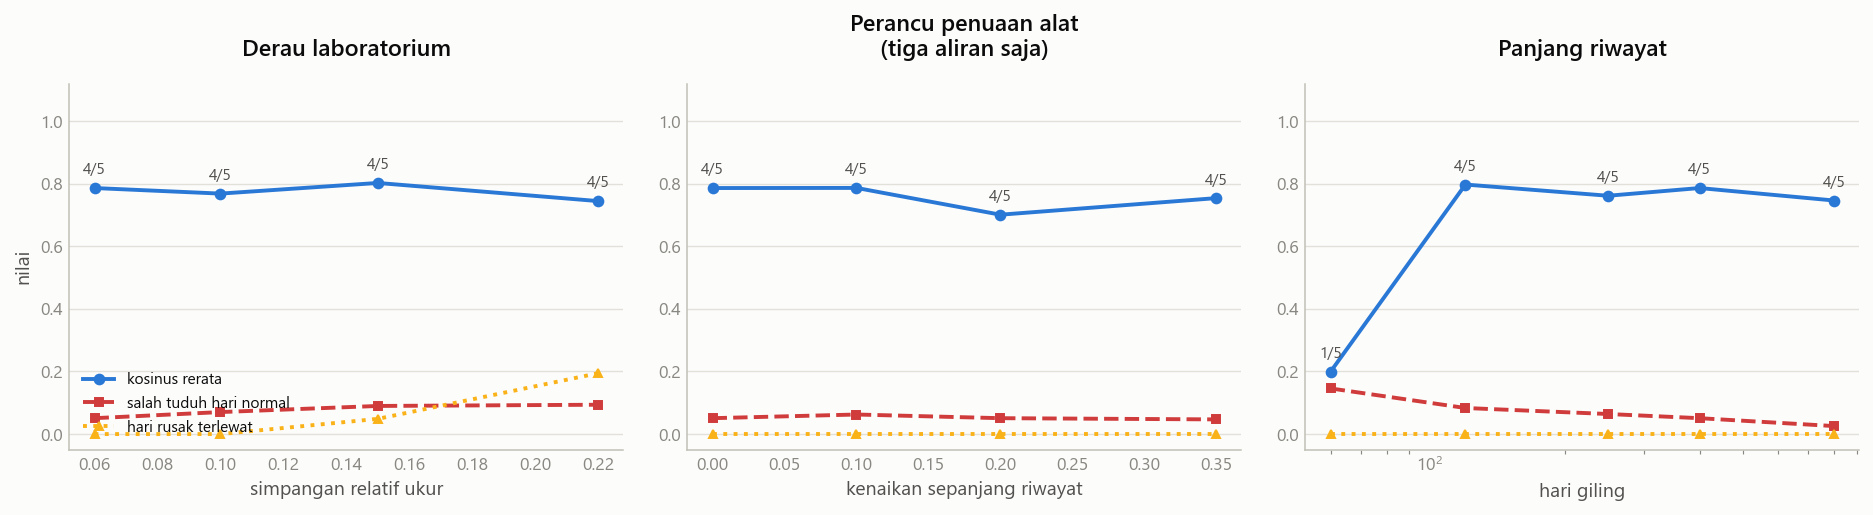

angka di atas titik = jumlah gangguan yang pulih dari 5

 n_hari  n_pola_ditemukan  pulih  kosinus_rerata  salah_tuduh
     60                 1      1           0.200        0.146
    120                 4      4           0.797        0.083
    250                 6      4           0.762        0.064
    400                 6      4           0.786        0.051
    800                 5      4           0.746        0.026


In [7]:
r_derau = pd.DataFrame([{k: v for k, v in RR.uji(400, ragam=r).items()
                         if k != "tabel"} for r in [0.06, 0.10, 0.15, 0.22]])
r_tua = pd.DataFrame([{k: v for k, v in
                       RR.uji(400, penuaan=p, terpilih=True).items()
                       if k != "tabel"} for p in [0.0, 0.10, 0.20, 0.35]])
r_hari = pd.DataFrame([{k: v for k, v in RR.uji(n).items() if k != "tabel"}
                       for n in [60, 120, 250, 400, 800]])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

def panel(ax, t, xk, judul, xlabel):
    x = t[xk].to_numpy()
    ax.plot(x, t["kosinus_rerata"], color=vs.CATEGORICAL[0], marker="o",
            markersize=5, label="kosinus rerata")
    ax.plot(x, t["salah_tuduh"], color=vs.STATUS["critical"], marker="s",
            markersize=4.5, linestyle="--", label="salah tuduh hari normal")
    ax.plot(x, t["terlewat"], color=vs.STATUS["warning"], marker="^",
            markersize=4.5, linestyle=":", label="hari rusak terlewat")
    for xi, yi, n in zip(x, t["kosinus_rerata"], t["pulih"]):
        ax.annotate(f"{int(n)}/5", (xi, yi), xytext=(0, 7),
                    textcoords="offset points", ha="center", fontsize=8,
                    color=vs.INK_SECONDARY)
    ax.set_xlabel(xlabel); ax.set_ylim(-0.05, 1.12); ax.set_title(judul)

panel(axes[0], r_derau, "ragam", "Derau laboratorium", "simpangan relatif ukur")
panel(axes[1], r_tua, "penuaan", "Perancu penuaan alat\n(tiga aliran saja)",
      "kenaikan sepanjang riwayat")
panel(axes[2], r_hari, "n_hari", "Panjang riwayat", "hari giling")
axes[2].set_xscale("log")
axes[0].set_ylabel("nilai")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); vs.show()

print("angka di atas titik = jumlah gangguan yang pulih dari 5")
print()
print(r_hari[["n_hari", "n_pola_ditemukan", "pulih", "kosinus_rerata",
              "salah_tuduh"]].round(3).to_string(index=False))

> **Derau laboratorium.** Sampai simpangan 22% — jauh di atas ketelitian
> laboratorium pabrik yang wajar — empat gangguan tetap pulih. Yang
> memburuk lebih dulu adalah hari rusak yang terlewat (0% → 19%), bukan
> tuduhan palsu. Arah kegagalannya benar: sistem jadi pendiam, bukan
> jadi asal tuduh.
>
> **Perancu berarah.** Penuaan yang hanya menyentuh tiga aliran adalah
> bentuk paling berbahaya, karena ia punya arah dan bisa disangka
> kerusakan. Pemulihan bertahan di 4/5 dan salah tuduh tetap di sekitar
> 5%. Perancu ini tidak melahirkan tuduhan baru.
>
> **Panjang riwayat.** Enam puluh hari **tidak cukup** — hanya satu pola
> yang muncul, kosinus 0,20. Mulai 120 hari sistem sudah berguna. Itu
> angka penerapan yang konkret: sekitar empat bulan giling sebelum
> modul atribusi boleh dinyalakan, dan sampai saat itu sistem hanya
> menyajikan neraca tanpa menunjuk sebab.

## 6. Bagaimana kalau koefisiennya sendiri salah?

Nisbah massa berstatus `perlu_verifikasi` — taksiran teknik, bukan
kutipan terbit. Pertanyaan yang wajar dari juri maupun pabrik: kalau
angka itu meleset, apakah kesimpulannya berubah?

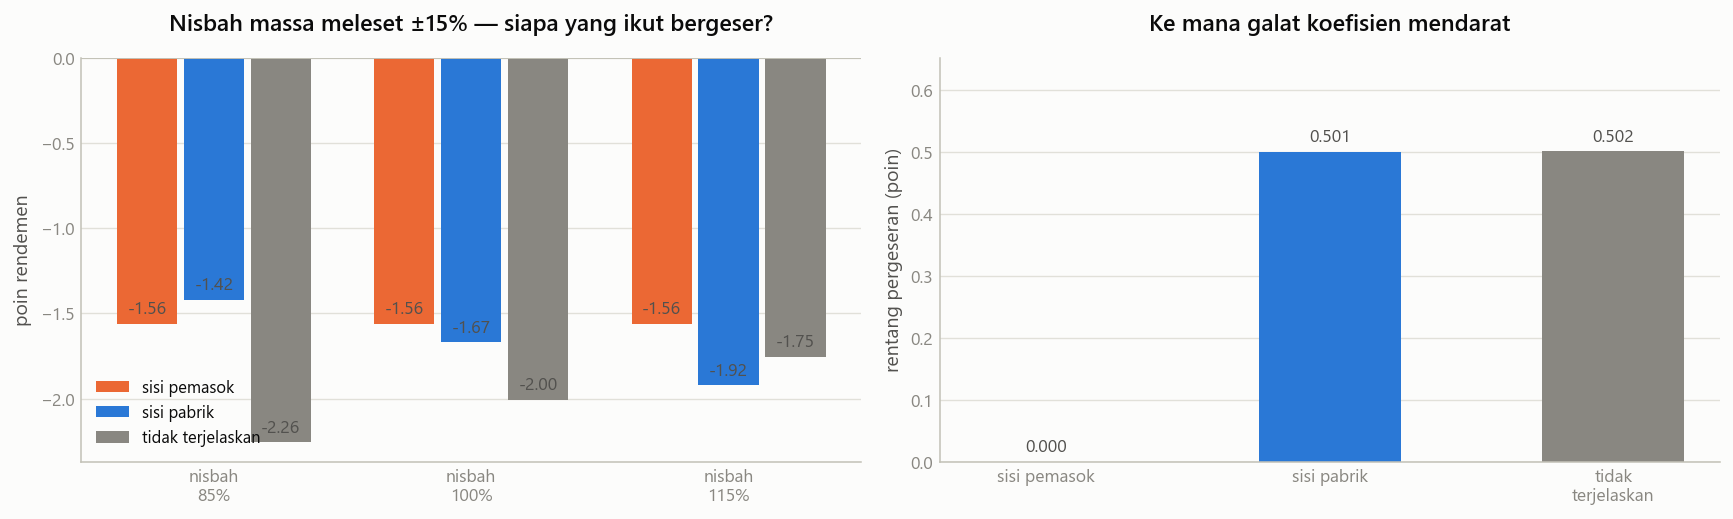

 faktor_nisbah          mode  pemasok_poin  pabrik_poin  tak_terjelaskan_poin  pangsa_pemasok
          0.85 terverifikasi         -1.56       -1.420                -2.256           0.298
          0.85       lengkap         -3.07       -1.915                -0.251           0.586
          1.00 terverifikasi         -1.56       -1.670                -2.005           0.298
          1.00       lengkap         -3.07       -2.165                -0.000           0.586
          1.15 terverifikasi         -1.56       -1.921                -1.754           0.298
          1.15       lengkap         -3.07       -2.416                 0.251           0.535


In [8]:
sens = RR.sensitivitas_koefisien(galat=0.15)
ket = sens[sens["mode"] == "terverifikasi"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))

ax = axes[0]
x = np.arange(len(ket)); w = 0.26
for i, (kol, warna, lab) in enumerate([
        ("pemasok_poin", W_PEMASOK, "sisi pemasok"),
        ("pabrik_poin", W_PABRIK, "sisi pabrik"),
        ("tak_terjelaskan_poin", W_SISA, "tidak terjelaskan")]):
    b = ax.bar(x + (i - 1) * w, ket[kol], width=w * 0.9, color=warna, label=lab)
    vs.label_bars(ax, b, fmt="{:.2f}")
ax.set_xticks(x)
ax.set_xticklabels([f"nisbah\n{f:.0%}" for f in ket["faktor_nisbah"]], fontsize=9)
ax.set_ylabel("poin rendemen")
ax.set_title("Nisbah massa meleset ±15% — siapa yang ikut bergeser?")
ax.legend(fontsize=8.5, loc="lower left")
ax.axhline(0, color=vs.BASELINE, linewidth=1)

ax = axes[1]
geser = {"sisi pemasok": ket["pemasok_poin"].max() - ket["pemasok_poin"].min(),
         "sisi pabrik": ket["pabrik_poin"].max() - ket["pabrik_poin"].min(),
         "tidak\nterjelaskan": (ket["tak_terjelaskan_poin"].max()
                                - ket["tak_terjelaskan_poin"].min())}
b = ax.bar(range(3), list(geser.values()),
           color=[W_PEMASOK, W_PABRIK, W_SISA], width=0.5)
vs.label_bars(ax, b, fmt="{:.3f}")
ax.set_xticks(range(3)); ax.set_xticklabels(list(geser), fontsize=9)
ax.set_ylabel("rentang pergeseran (poin)")
ax.set_title("Ke mana galat koefisien mendarat")
ax.set_ylim(0, max(geser.values()) * 1.3)
plt.tight_layout(); vs.show()

print(sens.to_string(index=False))

> **Tagihan pemasok tidak bergerak satu poin pun.** Galat koefisien
> pabrik mendarat seluruhnya di baris pabrik dan baris tak terjelaskan.
>
> Itu bukan kebetulan, melainkan akibat langsung dari struktur tiga
> baris: koefisien sisi pabrik tidak pernah masuk ke perhitungan potensi
> realistis. Sifat ini yang membuat sistem tetap aman dipasang meski
> sebagian angkanya belum sempurna — pihak yang paling lemah posisinya
> terlindung dari ketidaktahuan sistem, bukan menanggungnya.

## Kesimpulan

**Model 5 — neraca tiga baris**

| Yang diperiksa | Hasil |
|---|---|
| Galat penutupan aritmetika | 0,00e+00 (kedua mode) |
| Sisa tak terjelaskan, mode lengkap | tepat 0,000 poin |
| Pergeseran sisi pabrik saat mutu buah memburuk | **0,00e+00 poin** |
| Kekekalan pemasok + tak terjelaskan | 2,66e-15 poin |
| Pergeseran tagihan pemasok saat koefisien meleset ±15% | **0,000 poin** |

Dua sifat yang layak dibawa ke meja perundingan:

1. **Buah mentah tidak dihitung dua kali.** Sisi pabrik rata persis di
   nol sepanjang seluruh rentang mutu buah. Setiap poin yang ditambahkan
   ke tagihan pemasok diambil dari baris tak terjelaskan, bukan dicetak
   dari ketiadaan.

2. **Galat koefisien tidak jatuh ke petani.** Nisbah massa meleset ±15%
   menggeser baris pabrik dan baris tak terjelaskan sebesar 0,50 poin,
   sementara tagihan pemasok tidak bergerak sama sekali. Pihak yang
   paling lemah posisinya terlindung dari ketidaktahuan sistem, bukan
   menanggungnya.

Harga kehati-hatian juga terlihat: menolak tiga koefisien yang belum
tertelusur menurunkan pangsa pemasok dari 53% ke 27%, dan yang tidak
jadi dituduhkan muncul sebagai 35% ketidaktahuan yang diakui terbuka —
bukan dipindahkan diam-diam ke pabrik.

**Model 6 — atribusi tanpa label**

| Yang diperiksa | Hasil |
|---|---|
| Aturan yang pulih | **4 dari 5**, kosinus 0,931–0,9995 |
| Siluet kelompok | 0,837 |
| Salah tuduh hari normal | 5,1% |
| Hari rusak terlewat | 0,0% |
| Bertahan sampai derau ukur | 22% (4/5 tetap pulih) |
| Riwayat minimum yang berguna | **120 hari** |

Dua arah acak di ruang delapan dimensi rata-rata berkosinus nol dengan
simpangan sekitar 0,35. Kosinus 0,93–0,9995 terhadap pola yang tidak
pernah diperlihatkan bukan kebetulan — sistem menemukan kembali
hubungan sebab-akibat mekanis yang tidak diberitahukan padanya.

Arah kegagalannya juga benar. Saat derau naik, yang memburuk lebih
dulu adalah hari rusak yang terlewat (0% → 19%), bukan tuduhan palsu:
sistem jadi pendiam, bukan jadi asal tuduh.

**Batas yang harus disebut**

- `sludge_separator_tersumbat` **tidak** terpulihkan, dan sebabnya bisa
  dihitung: tanda tangannya berimpit dengan `cst_dingin`. Tidak ada
  metode tanpa label yang bisa memisahkan dua sebab yang meninggalkan
  jejak sama. Menembusnya butuh sensor tambahan, bukan lapisan jaringan
  tambahan.

- **60 hari tidak cukup.** Modul atribusi baru boleh dinyalakan setelah
  sekitar empat bulan giling. Sampai saat itu sistem menyajikan neraca
  tanpa menunjuk sebab — dan itu harus jadi perilaku bawaan saat
  dipasang, bukan catatan kaki.

- Seluruh pengujian ini berjalan di atas simulator. Yang terbukti adalah
  **aritmetika neracanya benar** dan **atribusinya memulihkan gangguan
  yang ditanam** — bukan bahwa angkanya cocok dengan pabrik tertentu.
  Nisbah massa yang mengubah kadar laboratorium menjadi poin rendemen
  masih berstatus `perlu_verifikasi`, dan harus diganti dengan nisbah
  terukur dari satu pabrik nyata sebelum sistem ini boleh menyentuh
  keputusan pembayaran.

---

Modul AI inti selesai. Berikutnya: menyambungkan Model 1–6 ke endpoint
backend dan kartu neraca di antarmuka.